# Heart failure: predicting mortality from clinical records

**Goal:** estimate the risk that a heart-failure patient dies during follow-up, from 11 clinical features
(age, ejection fraction, serum creatinine and sodium, CPK, platelets, anaemia, diabetes, blood pressure, sex, smoking).

**Key points of this notebook:**
1. **73.6% of the rows are exact duplicates.** With duplicates in both train and test, the first version of this project reported 99% accuracy.
2. The **`time` (follow-up period)** column leaks the outcome: patients who die have short follow-up because they died.
3. This 5,000-row file is a synthetic expansion of ~300 real patients, so cross-validation keeps similar patients in the same fold.
4. Accuracy is misleading with 30% positives, so ROC-AUC, PR-AUC and recall are reported instead.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import heart_model as hm

pd.set_option("display.float_format", "{:.3f}".format)
raw = pd.read_csv(hm.DATA_PATH)
print(raw.shape)
raw.head()

(5000, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,55.000,0,748,0,45,0,263358.030,1.300,137,1,1,88,0
1,65.000,0,56,0,25,0,305000.000,5.000,130,1,0,207,0
2,45.000,0,582,1,38,0,319000.000,0.900,140,0,0,244,0
3,60.000,1,754,1,40,1,328000.000,1.200,126,1,0,90,0
4,95.000,1,582,0,30,0,461000.000,2.000,132,1,0,50,1


## 1. Data quality

In [2]:
print(f"Exact duplicate rows: {raw.duplicated().sum():,} of {len(raw):,} ({raw.duplicated().mean():.1%})")
df = hm.load_data()
print(f"Unique rows: {len(df):,} | death rate: {df[hm.TARGET].mean():.1%}")
print("Distinct ages:", df["age"].nunique(), "| distinct platelet values:", df["platelets"].nunique(),
      "-> rows are recombinations of a small set of real patients")

Exact duplicate rows: 3,680 of 5,000 (73.6%)
Unique rows: 1,320 | death rate: 30.1%
Distinct ages: 48 | distinct platelet values: 203 -> rows are recombinations of a small set of real patients


## 2. Why `time` must go

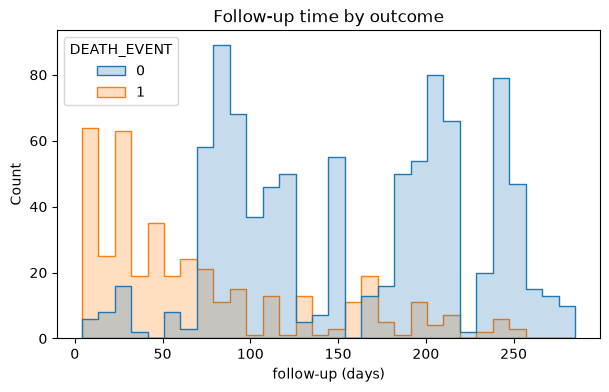

DEATH_EVENT
0   172.000
1    45.000
Name: time, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df, x="time", hue=hm.TARGET, bins=30, ax=ax, element="step")
ax.set(title="Follow-up time by outcome", xlabel="follow-up (days)")
plt.show()
print(df.groupby(hm.TARGET)["time"].median())

Patients who died have a much shorter follow-up. The model would learn "short follow-up = death", but at prediction
time the follow-up length is unknown. The column is therefore dropped.

## 3. Exploratory analysis

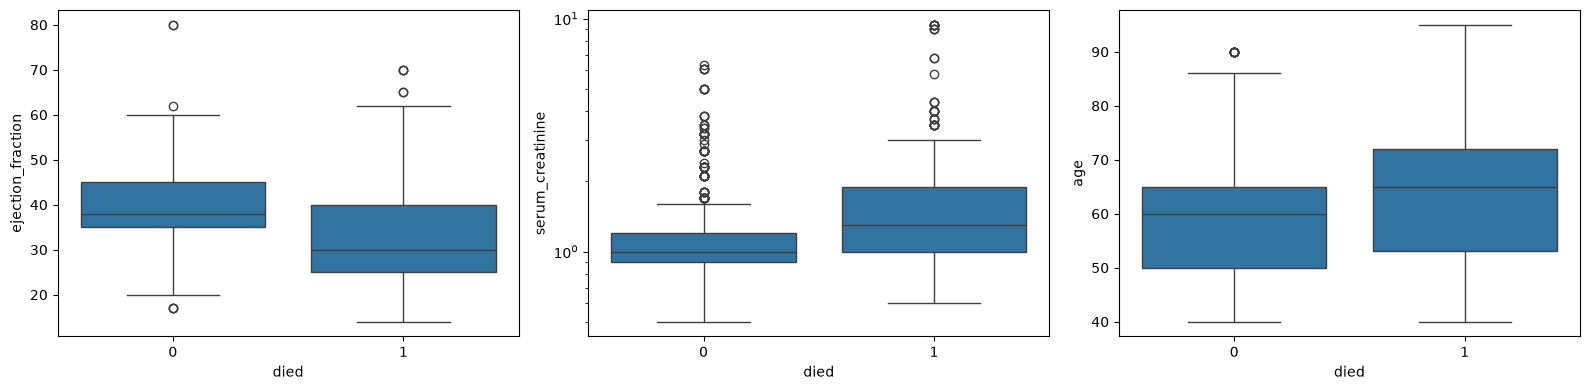

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df, x=hm.TARGET, y="ejection_fraction", ax=axes[0])
sns.boxplot(data=df, x=hm.TARGET, y="serum_creatinine", ax=axes[1]); axes[1].set_yscale("log")
sns.boxplot(data=df, x=hm.TARGET, y="age", ax=axes[2])
for ax in axes: ax.set_xlabel("died")
plt.tight_layout()

In [5]:
binary = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]
pd.DataFrame({f: df.groupby(f)[hm.TARGET].mean() for f in binary}).T.rename(columns={0: "death rate if 0", 1: "death rate if 1"})

,death rate if 0,death rate if 1
anaemia,0.272,0.331
diabetes,0.301,0.300
high_blood_pressure,0.261,0.369
sex,0.274,0.316
smoking,0.299,0.305


Low ejection fraction, high serum creatinine and older age are clearly associated with death. The binary conditions make
a much smaller difference.

## 4. Model comparison (5-fold stratified group CV)

The baseline is a logistic regression on just ejection fraction and serum creatinine, the two features medical studies
of the original data highlight.

In [6]:
cv = hm.cross_validate_models(df)
cv

,ROC-AUC,PR-AUC,Recall,Precision,ROC-AUC std,PR-AUC std,Recall std,Precision std
Model,,,,,,,,
Baseline: logistic regression on ejection fraction + creatinine,0.762,0.637,0.703,0.566,0.092,0.141,0.082,0.117
Logistic regression (all features),0.780,0.619,0.688,0.549,0.075,0.100,0.150,0.133
Random forest,0.850,0.754,0.689,0.631,0.060,0.090,0.063,0.108


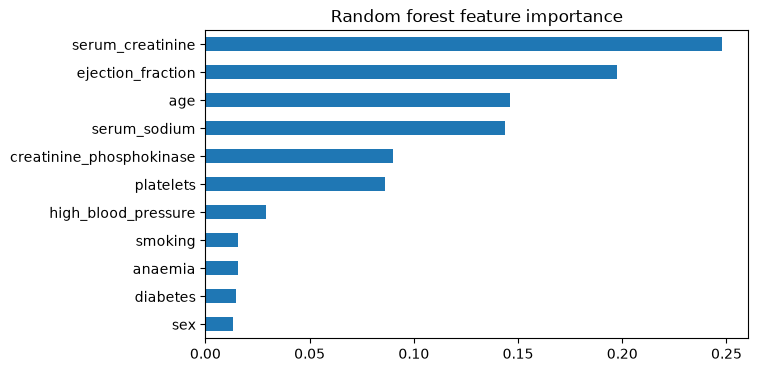

In [7]:
model = hm.train_final(df)
hm.feature_importance(model).sort_values().plot.barh(figsize=(7, 4), title="Random forest feature importance")
plt.show()

## 5. Conclusions

- Removing duplicates and the leaky `time` column changes the story completely: the honest random-forest **ROC-AUC is ≈ 0.85**,
  with recall ≈ 0.69 at the default threshold. The earlier "99% accuracy" was not real.
- A two-feature logistic regression (ejection fraction + serum creatinine) already reaches ROC-AUC ≈ 0.76, which makes it a strong, interpretable baseline.
- Because the data is a synthetic expansion of ~300 patients, these scores are still likely **optimistic**. A real-world
  model would need to be validated on an independent patient cohort.
- In a screening setting, missing a high-risk patient is worse than a false alarm, so the decision threshold should
  be chosen for high recall and agreed with clinicians.